# Deep SVDD Training and Evaluation Notebook

This notebook trains the convolutional Deep SVDD baseline on the processed WM-811K split and evaluates it with the same anomaly-detection protocol used for the autoencoder and VAE.

Workflow:
- load `configs/training/train_svdd.toml`
- initialize the SVDD center from the training-normal embeddings
- train on normal wafers only
- save checkpoints and history under the configured artifact directory
- derive a threshold from validation-normal scores
- evaluate on the test split with shared metrics


In [1]:
from pathlib import Path
import json
import random
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display
from torch.utils.data import DataLoader

cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
REPO_ROOT = None
for candidate in candidate_roots:
    if (candidate / "src" / "wafer_defect").exists() and (candidate / "configs").exists():
        REPO_ROOT = candidate
        break

if REPO_ROOT is None:
    raise RuntimeError("Could not locate repo root containing src/wafer_defect and configs/")

SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from wafer_defect.config import load_toml
from wafer_defect.data.wm811k import WaferMapDataset
from wafer_defect.evaluation.reconstruction_metrics import summarize_threshold_metrics, sweep_threshold_metrics
from wafer_defect.models.svdd import ConvDeepSVDD
from wafer_defect.scoring import svdd_distance
from wafer_defect.training.svdd import initialize_svdd_center, run_svdd_epoch


In [2]:
config_path = REPO_ROOT / "configs" / "training" / "train_svdd.toml"
config = load_toml(config_path)

# Optional quick smoke-run override:
# config["data"]["metadata_csv"] = "data/processed/x64/wm811k/metadata_dev.csv"
# config["training"]["epochs"] = 3
# config["run"]["output_dir"] = "artifacts/x64/svdd_dev"
# config["training"]["resume_from"] = "artifacts/x64/svdd_baseline/latest_checkpoint.pt"

display(config)


{'run': {'output_dir': 'artifacts/x64/svdd_baseline', 'seed': 42},
 'data': {'metadata_csv': 'data/processed/x64/wm811k/metadata_50k_5pct.csv',
  'image_size': 64,
  'batch_size': 64,
  'num_workers': 0},
 'training': {'epochs': 30,
  'learning_rate': 0.0005,
  'weight_decay': 1e-05,
  'device': 'auto',
  'early_stopping_patience': 5,
  'early_stopping_min_delta': 0.0001,
  'checkpoint_every': 5,
  'resume_from': ''},
 'model': {'type': 'svdd', 'latent_dim': 128, 'center_eps': 0.1}}

In [3]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    torch.manual_seed(seed)


def resolve_device(device_name: str) -> torch.device:
    if device_name == "auto":
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")
    return torch.device(device_name)


In [4]:
set_seed(int(config["run"]["seed"]))
device = resolve_device(config["training"]["device"])
output_dir = REPO_ROOT / config["run"]["output_dir"]
output_dir.mkdir(parents=True, exist_ok=True)

image_size = int(config["data"].get("image_size", 64))
center_eps = float(config["model"].get("center_eps", 0.1))

train_dataset = WaferMapDataset(config["data"]["metadata_csv"], split="train", image_size=image_size)
val_dataset = WaferMapDataset(config["data"]["metadata_csv"], split="val", image_size=image_size)
test_dataset = WaferMapDataset(config["data"]["metadata_csv"], split="test", image_size=image_size)

train_loader = DataLoader(
    train_dataset,
    batch_size=int(config["data"]["batch_size"]),
    shuffle=True,
    num_workers=int(config["data"]["num_workers"]),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=int(config["data"]["batch_size"]),
    shuffle=False,
    num_workers=int(config["data"]["num_workers"]),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=int(config["data"]["batch_size"]),
    shuffle=False,
    num_workers=int(config["data"]["num_workers"]),
)

model = ConvDeepSVDD(
    latent_dim=int(config["model"]["latent_dim"]),
    image_size=image_size,
).to(device)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=float(config["training"]["learning_rate"]),
    weight_decay=float(config["training"]["weight_decay"]),
)

patience = int(config["training"].get("early_stopping_patience", 0))
min_delta = float(config["training"].get("early_stopping_min_delta", 0.0))
checkpoint_every = int(config["training"].get("checkpoint_every", 5))
resume_from = str(config["training"].get("resume_from", "")).strip()

print(f"""
Device: {device}
Output dir: {output_dir}
Center eps: {center_eps}
Resume from: {resume_from or 'fresh run'}

Train samples: {len(train_dataset)}
Val samples: {len(val_dataset)}
Test samples: {len(test_dataset)}
""")



Device: cuda
Output dir: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\artifacts\x64\svdd_baseline
Center eps: 0.1

Train samples: 40000
Val samples: 5000
Test samples: 5250



In [5]:
print(model)


ConvDeepSVDD(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1, inplace=True)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.1, inplace=True)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.1, inplace=True)
    (9): Flatten(start_dim=1, end_dim=-1)
    (10): Linear(in_features=4096, out_features=128, bias=False)
  )
)


In [6]:
history = []
history_df = None
training_summary = None

best_val_loss = float("inf")
best_epoch = 0
stale_epochs = 0
start_epoch = 0

if resume_from:
    resume_path = Path(resume_from)
    if not resume_path.is_absolute():
        resume_path = REPO_ROOT / resume_path
    checkpoint = torch.load(resume_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = int(checkpoint.get("epoch", 0))
    best_val_loss = float(checkpoint.get("best_val_loss", best_val_loss))
    best_epoch = int(checkpoint.get("best_epoch", best_epoch))
    stale_epochs = int(checkpoint.get("stale_epochs", stale_epochs))
    history = checkpoint.get("history", [])
    print({
        "resumed_from": str(resume_path),
        "start_epoch": start_epoch,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "center_norm": float(model.center.norm().item()),
    })
else:
    center = initialize_svdd_center(model, train_loader, device, eps=center_eps)
    model.set_center(center)
    print({"center_norm": float(model.center.norm().item())})

for epoch in range(start_epoch, int(config["training"]["epochs"])):
    train_metrics = run_svdd_epoch(model, train_loader, device, optimizer)
    val_metrics = run_svdd_epoch(model, val_loader, device)

    record = {
        "epoch": epoch + 1,
        "train_loss": train_metrics.loss,
        "val_loss": val_metrics.loss,
    }
    history.append(record)
    print(record)

    improved = (best_val_loss - val_metrics.loss) > min_delta
    if improved:
        best_val_loss = val_metrics.loss
        best_epoch = epoch + 1
        stale_epochs = 0
        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "config": config,
                "best_epoch": best_epoch,
                "best_val_loss": best_val_loss,
                "stale_epochs": stale_epochs,
                "history": history,
            },
            output_dir / "best_model.pt",
        )
    else:
        stale_epochs += 1

    latest_checkpoint = {
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "config": config,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "stale_epochs": stale_epochs,
        "history": history,
    }
    torch.save(latest_checkpoint, output_dir / "latest_checkpoint.pt")

    if checkpoint_every > 0 and (epoch + 1) % checkpoint_every == 0:
        torch.save(latest_checkpoint, output_dir / f"checkpoint_epoch_{epoch + 1}.pt")

    if patience > 0 and stale_epochs >= patience:
        print(
            f"Early stopping at epoch {epoch + 1}. "
            f"Best epoch: {best_epoch}, best val loss: {best_val_loss:.6f}"
        )
        break

torch.save(
    {
        "epoch": len(history),
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "config": config,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "stale_epochs": stale_epochs,
        "history": history,
    },
    output_dir / "last_model.pt",
)

with (output_dir / "history.json").open("w", encoding="utf-8") as handle:
    json.dump(history, handle, indent=2)

training_summary = {
    "best_epoch": best_epoch,
    "best_val_loss": best_val_loss,
    "epochs_ran": len(history),
    "center_norm": float(model.center.norm().item()),
    "resumed_from": resume_from,
}
with (output_dir / "summary.json").open("w", encoding="utf-8") as handle:
    json.dump(training_summary, handle, indent=2)

history_df = pd.DataFrame(history)
display(history_df.tail())
training_summary


{'center_norm': 1.1313709020614624}
{'epoch': 1, 'train_loss': 0.7321180343449116, 'val_loss': 0.063393381524086}
{'epoch': 2, 'train_loss': 0.04593832279741764, 'val_loss': 0.026552213114500046}
{'epoch': 3, 'train_loss': 0.0328869205236435, 'val_loss': 0.025819981014728547}
{'epoch': 4, 'train_loss': 0.02858115926980972, 'val_loss': 0.019770891109108926}
{'epoch': 5, 'train_loss': 0.029110278299450874, 'val_loss': 0.019344909250736238}
{'epoch': 6, 'train_loss': 0.02124022137671709, 'val_loss': 0.013477396745979786}
{'epoch': 7, 'train_loss': 0.018376796302199364, 'val_loss': 0.029619659692049025}
{'epoch': 8, 'train_loss': 0.01417533867135644, 'val_loss': 0.009806654898822308}
{'epoch': 9, 'train_loss': 0.01216209810078144, 'val_loss': 0.005400431032478809}
{'epoch': 10, 'train_loss': 0.010472963095456362, 'val_loss': 0.0049810723587870595}
{'epoch': 11, 'train_loss': 0.008738900282606482, 'val_loss': 0.0034318842589855193}
{'epoch': 12, 'train_loss': 0.01076966228876263, 'val_loss'

,epoch,train_loss,val_loss
23,24,0.000428,0.000498
24,25,0.001197,0.002093
25,26,0.003190,0.009926
26,27,0.011506,0.001011
27,28,0.000945,0.000340


{'best_epoch': 23,
 'best_val_loss': 0.0001811512232758105,
 'epochs_ran': 28,
 'center_norm': 1.1313709020614624}

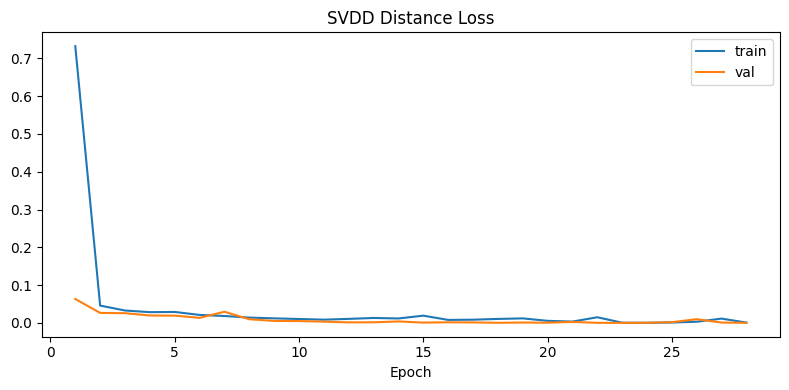

In [7]:
history_df = pd.DataFrame(history)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_df["epoch"], history_df["train_loss"], label="train")
ax.plot(history_df["epoch"], history_df["val_loss"], label="val")
ax.set_title("SVDD Distance Loss")
ax.set_xlabel("Epoch")
ax.legend()

plt.tight_layout()
plt.show()


In [8]:
def collect_scores(model: ConvDeepSVDD, dataloader: DataLoader, device: torch.device) -> pd.DataFrame:
    rows = []
    sample_index = 0
    model.eval()
    with torch.inference_mode():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            embeddings = model(inputs)
            scores = svdd_distance(embeddings, model.center)
            for score, label in zip(scores.cpu().tolist(), labels.tolist()):
                rows.append({"sample_index": sample_index, "score": float(score), "is_anomaly": int(label)})
                sample_index += 1

    return pd.DataFrame(rows)


best_model_path = output_dir / "best_model.pt"
if not best_model_path.exists():
    raise FileNotFoundError(f"Best checkpoint not found: {best_model_path}")

checkpoint = torch.load(best_model_path, map_location=device)
eval_model = ConvDeepSVDD(
    latent_dim=int(config["model"]["latent_dim"]),
    image_size=image_size,
).to(device)
eval_model.load_state_dict(checkpoint["model_state_dict"])
print({
    "evaluation_checkpoint": str(best_model_path),
    "loaded_epoch": int(checkpoint.get("epoch", -1)),
    "loaded_best_epoch": int(checkpoint.get("best_epoch", checkpoint.get("epoch", -1))),
})

val_scores_df = collect_scores(eval_model, val_loader, device)
test_scores_df = collect_scores(eval_model, test_loader, device)

threshold = float(val_scores_df.loc[val_scores_df["is_anomaly"] == 0, "score"].quantile(0.95))
labels = test_scores_df["is_anomaly"].to_numpy()
scores = test_scores_df["score"].to_numpy()

metrics = summarize_threshold_metrics(labels, scores, threshold)
threshold_sweep_df, best_sweep = sweep_threshold_metrics(labels, scores)

evaluation_dir = output_dir / "evaluation_notebook"
evaluation_dir.mkdir(parents=True, exist_ok=True)
val_scores_df.to_csv(evaluation_dir / "val_scores.csv", index=False)
test_scores_df.to_csv(evaluation_dir / "test_scores.csv", index=False)
threshold_sweep_df.to_csv(evaluation_dir / "threshold_sweep.csv", index=False)

evaluation_summary = {
    "checkpoint": str(best_model_path),
    "threshold": threshold,
    "metrics_at_validation_threshold": metrics,
    "best_threshold_sweep": best_sweep,
}
with (evaluation_dir / "summary.json").open("w", encoding="utf-8") as handle:
    json.dump(evaluation_summary, handle, indent=2)

display(pd.DataFrame([metrics]))
display(pd.DataFrame([best_sweep]))
evaluation_summary


,threshold,precision,recall,f1,auroc,auprc,predicted_anomalies,confusion_matrix
0,0.000304,0.304709,0.44,0.360065,0.787506,0.213108,361,"[[4749, 251], [140, 110]]"


,threshold,precision,recall,f1,predicted_anomalies
0,0.000302,0.307902,0.452,0.366288,366


{'threshold': 0.00030369335727300497,
 'metrics_at_validation_threshold': {'threshold': 0.00030369335727300497,
  'precision': 0.3047091412742382,
  'recall': 0.44,
  'f1': 0.36006546644844517,
  'auroc': 0.7875064,
  'auprc': 0.21310835831292738,
  'predicted_anomalies': 361,
  'confusion_matrix': [[4749, 251], [140, 110]]},
 'best_threshold_sweep': {'threshold': 0.0003024059988092631,
  'precision': 0.3079019073569482,
  'recall': 0.452,
  'f1': 0.3662884927061631,
  'predicted_anomalies': 366}}

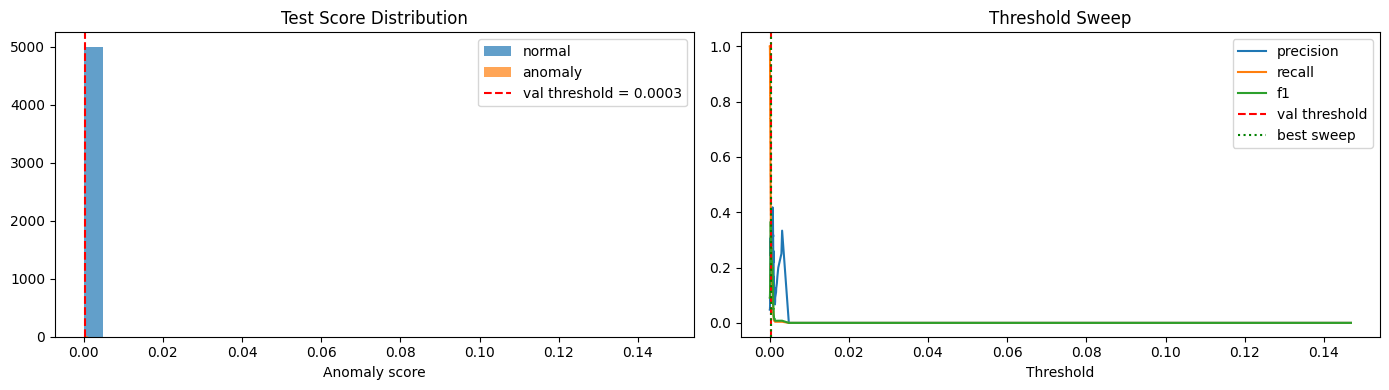

,threshold,precision,recall,f1,predicted_anomalies
4880,0.000302,0.307902,0.452,0.366288,366
4879,0.000302,0.307065,0.452,0.365696,367
4878,0.000302,0.306233,0.452,0.365105,368
4877,0.000301,0.305405,0.452,0.364516,369
4882,0.000303,0.306849,0.448,0.364228,364
4871,0.000300,0.303191,0.456,0.364217,375
4876,0.000301,0.304582,0.452,0.363929,370
4870,0.000299,0.302387,0.456,0.363636,376
4881,0.000303,0.306011,0.448,0.363636,365
4875,0.000301,0.303763,0.452,0.363344,371


In [9]:
focus_low = float(threshold_sweep_df["threshold"].quantile(0.01))
focus_high = float(threshold_sweep_df["threshold"].quantile(0.99))
focus_low = min(focus_low, threshold, best_sweep["threshold"])
focus_high = max(focus_high, threshold, best_sweep["threshold"])
focus_pad = max((focus_high - focus_low) * 0.1, 1e-6)
focus_low = max(0.0, focus_low - focus_pad)
focus_high = focus_high + focus_pad

fig, axes = plt.subplots(1, 3, figsize=(20, 4))

axes[0].hist(test_scores_df.loc[test_scores_df["is_anomaly"] == 0, "score"], bins=30, alpha=0.7, label="normal")
axes[0].hist(test_scores_df.loc[test_scores_df["is_anomaly"] == 1, "score"], bins=30, alpha=0.7, label="anomaly")
axes[0].axvline(threshold, color="red", linestyle="--", label=f"val threshold = {threshold:.4f}")
axes[0].set_title("Test Score Distribution")
axes[0].set_xlabel("Anomaly score")
axes[0].legend()

for axis in axes[1:]:
    axis.plot(threshold_sweep_df["threshold"], threshold_sweep_df["precision"], label="precision")
    axis.plot(threshold_sweep_df["threshold"], threshold_sweep_df["recall"], label="recall")
    axis.plot(threshold_sweep_df["threshold"], threshold_sweep_df["f1"], label="f1")
    axis.axvline(threshold, color="red", linestyle="--", label="val threshold")
    axis.axvline(best_sweep["threshold"], color="green", linestyle=":", label="best sweep")
    axis.set_xlabel("Threshold")

axes[1].set_title("Threshold Sweep (Full)")
axes[1].legend()

axes[2].set_title("Threshold Sweep (Zoomed)")
axes[2].set_xlim(focus_low, focus_high)
axes[2].legend()

plt.tight_layout()
plt.show()

display(threshold_sweep_df.sort_values("f1", ascending=False).head(10))


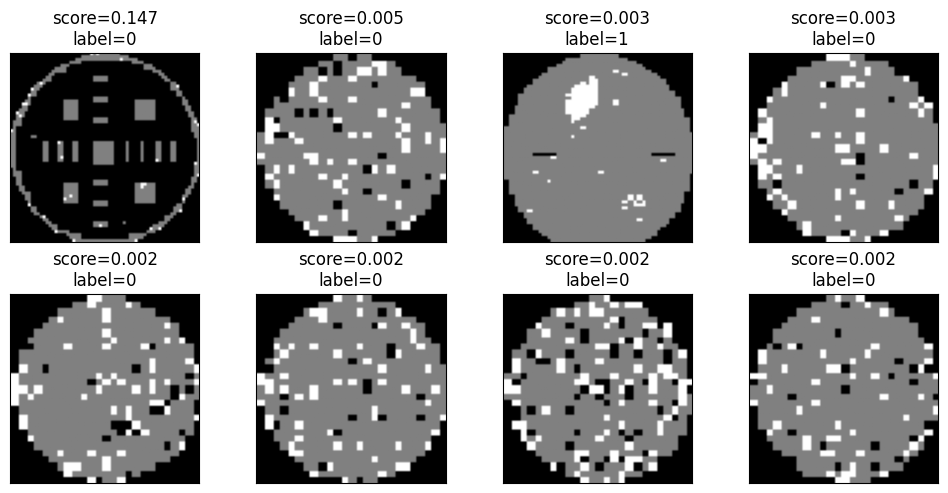

In [10]:
ranked_test_scores_df = test_scores_df.sort_values("score", ascending=False).reset_index(drop=True)
top_k = 8

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for idx in range(top_k):
    row = ranked_test_scores_df.iloc[idx]
    wafer_map, label = test_dataset[int(row["sample_index"])]
    ax = axes[idx // 4, idx % 4]
    ax.imshow(wafer_map[0], cmap="gray")
    ax.set_title(f"score={row['score']:.3f}\nlabel={int(label)}")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()
